# 13 · Neural networks and autoencoders for EEG

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Train a small temporal CNN and a denoising autoencoder using training-only normalization; compare what their losses actually measure.

**Data:** EEGBCI subject 1, runs 4/8/12; optional PyTorch

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## The question for today

A convolutional network can learn features directly from EEG, but a small dataset makes it easy to learn recording-specific shortcuts. We build a deliberately compact model, inspect its training process and compare reconstruction with classification as two different objectives.

### By the end you should be able to

- Track batch, channel and time dimensions through a temporal network.
- Explain logits, cross-entropy and gradient-based learning.
- Use a validation run for model selection and preserve a final test run.
- Distinguish reconstruction quality from physiological denoising and decoding utility.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The worked examples use small controlled arrays; the later walkthrough uses the dataset stated above. End-of-lesson exercises contain editable workspaces. A pending exercise message is expected until you complete its function.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


### Learned features still need an experimental design

A neural network replaces some hand-designed feature operations with trainable transformations. It does not replace channel inspection, correct event labels or independent evaluation. With a small number of EEG trials, the model can memorize quirks of one recording. The compact architecture here is a teaching baseline, not a claim that deep learning outperforms CSP.

PyTorch `Conv1d` expects batch × channel × time. A temporal kernel has a finite support and slides across the time axis. With stride one and suitable padding, the output retains the time length while changing the number of feature channels. Nonlinear activation allows later layers to express more than one linear transformation. Pooling summarizes time; a final linear layer maps the representation to class logits.

For $C_{in}$ input channels, $C_{out}$ output channels and kernel size $K$, a convolution with one bias per output channel contains

$$C_{out}(C_{in}K+1)$$

parameters. Counting parameters helps make capacity concrete. It does not by itself determine how much data a model needs, because regularization, task structure and signal quality also matter.

### Scores, probabilities and the loss

The network outputs logits $z_k$, unrestricted real-valued scores. Softmax converts them to probabilities,

$$p_k=\frac{e^{z_k}}{\sum_j e^{z_j}},\qquad \mathcal L=-\frac1N\sum_n\log p_{n,y_n}.$$

For numerical stability, a common constant can be subtracted from the logits before exponentiation. PyTorch cross-entropy takes logits directly and handles the stable calculation internally; do not apply softmax before passing outputs to that loss.

Backpropagation computes derivatives of the loss with respect to weights. An optimizer updates the weights to reduce training loss. Learning rate controls step size; too large can make optimization unstable, while too small can make progress slow. Training loss alone cannot tell us whether the representation transfers to new recordings.

### Three separate roles for three runs

The training run fits normalization and network weights. The validation run selects a checkpoint and supports limited development. The final test run is used once for evaluation of the selected model. Normalization uses only training statistics and preserves the same channel order for all partitions. If validation performance is repeatedly inspected while redesigning the model, that run has become part of development; the untouched test run remains necessary.

A random seed improves repeatability but does not turn one run split into population evidence. CPU/GPU kernels and library changes can also affect numerical reproducibility. Report the architecture, seed, optimizer, epoch budget and split, and compare a simple baseline under the same protocol before arguing for a more complex method.

### Autoencoding is a different learning problem

An autoencoder maps input to a compact representation and reconstructs it. Mean squared error is $\|\hat X-X\|^2/N_{elements}$. A denoising exercise adds known synthetic corruption and predicts the original measured EEG. That target is not perfectly clean brain activity: it already contains biological and recording artifacts. Improved reconstruction against this target establishes resistance to the injected noise, not removal of every real artifact or preservation of every task signal.

### Worked example · stable softmax

Turn logits into probabilities after subtracting their maximum. Show that a shared offset has no effect.

**Before running:** state your prediction and the assumption behind it.

In [2]:
demo_logits=np.array([2.,1.,-1.])
def demo_softmax(z):
    ex=np.exp(z-z.max());return ex/ex.sum()
print('Probabilities:',demo_softmax(demo_logits))
assert np.allclose(demo_softmax(demo_logits),demo_softmax(demo_logits+1000))

Probabilities: [0.70538451 0.25949646 0.03511903]


**Read the result.** Only relative logits matter. Subtracting the maximum avoids unnecessary overflow without changing the result.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · count convolution parameters

Compare two layer widths while keeping channels and kernel length fixed.

**Before running:** state your prediction and the assumption behind it.

In [3]:
for output_channels in [8,16,32]:
    print(output_channels,'feature channels:',output_channels*(3*15+1),'parameters')

8 feature channels: 368 parameters
16 feature channels: 736 parameters
32 feature channels: 1472 parameters


**Read the result.** Increasing width adds trainable capacity even when the input trial count stays fixed.

**Pause and explain:** point to one computed value that supports this interpretation.

### Guided experiment · cross-entropy penalizes confident errors

Evaluate the loss for several probabilities assigned to the correct class.

**Before running:** state your prediction and the assumption behind it.

In [4]:
demo_correct_probability=np.array([.99,.8,.5,.1,.01])
print(pd.DataFrame({'Correct-class probability':demo_correct_probability,'Loss':-np.log(demo_correct_probability)}))

   Correct-class probability      Loss
0                       0.99  0.010050
1                       0.80  0.223144
2                       0.50  0.693147
3                       0.10  2.302585
4                       0.01  4.605170


**Read the result.** Two models with the same hard-label accuracy can have very different cross-entropy because their confidence differs.

**Pause and explain:** point to one computed value that supports this interpretation.

### Checkpoint · reconstruction targets matter

Compare a zero predictor with a predictor that preserves a small event but misses a large background.

**Before running:** state your prediction and the assumption behind it.

In [5]:
demo_target=np.array([10.,10.,1.,0.])
demo_preserve_background=np.array([10.,10.,0.,0.])
demo_preserve_event=np.array([0.,0.,1.,0.])
print('MSE, background preserved:',np.mean((demo_target-demo_preserve_background)**2))
print('MSE, event preserved:',np.mean((demo_target-demo_preserve_event)**2))

MSE, background preserved: 0.25
MSE, event preserved: 50.0


**Read the result.** MSE is dominated by large-amplitude terms. A low reconstruction loss need not preserve the small feature needed for a BCI decision.

**Pause and explain:** point to one computed value that supports this interpretation.

## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

A temporal convolution computes $h_{k,t}=\phi(b_k+\sum_{c,\tau}W_{kc\tau}X_{c,t-\tau})$. Weight sharing reduces parameter count relative to a fully connected network. Cross-entropy $L=-N^{-1}\sum_i\log p_\theta(y_i|X_i)$ rewards correct class probabilities. Dropout and weight decay regularize but do not replace independent evaluation.

An autoencoder maps $z=f_\theta(X)$ and $\hat X=g_\phi(z)$, minimizing $\|X-\hat X\|^2$. A denoising autoencoder receives deliberately corrupted $\tilde X$ while targeting $X$. Real EEG used as a target is not artifact-free ground truth; low reconstruction error can preserve artifacts or suppress discriminative transients. A bottleneck is a modeling assumption, not evidence of neural source recovery.

Use one run for training, one for validation and one for testing. Fit channel scaling on training samples only. Select the best epoch from validation loss and evaluate the test run once. This small-data exercise is not intended to establish deep-learning superiority over CSP/LDA.

## Load EEG and PyTorch
CPU execution is sufficient. PyTorch is optional for the rest of the course.

The three runs have separate training, validation and test roles. Training-only normalization is applied consistently to all partitions; tensors retain the batch × channel × time organization required by Conv1d.

In [6]:
from mne.datasets import eegbci
runs = [4, 8, 12]  # ALL are imagined left versus right fist, not hands versus feet
parts, groups = [], []
for run in runs:
    paths = eegbci.load_data(1, [run], path=DATA_ROOT, update_path=False)
    raw_run = mne.io.read_raw_edf(paths[0], preload=True, verbose=False)
    eegbci.standardize(raw_run)
    raw_run.set_montage('standard_1005')
    raw_run.set_eeg_reference('average', projection=False)
    raw_run.filter(8, 30, fir_design='firwin')
    events, _ = mne.events_from_annotations(raw_run, event_id={'T1': 1, 'T2': 2})
    ep = mne.Epochs(raw_run, events, {'left': 1, 'right': 2}, tmin=0.5,
                    tmax=3.5, baseline=None, preload=True, picks='eeg',
                    reject_by_annotation=True)
    parts.append(ep)
    groups.extend([run] * len(ep))
epochs = mne.concatenate_epochs(parts)
X = epochs.get_data(copy=True)
y = epochs.events[:, 2] - 1
groups = np.asarray(groups)
print('Epochs:', X.shape, 'run counts:', pd.Series(groups).value_counts().to_dict())

import importlib.util
if importlib.util.find_spec('torch') is None:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','torch'])
import torch
from torch import nn
torch.manual_seed(SEED)
torch.set_num_threads(2)
tr=groups==4; va=groups==8; te=groups==12
mu=X[tr].mean(axis=(0,2),keepdims=True)
sd=X[tr].std(axis=(0,2),keepdims=True).clip(1e-12)
Z=torch.tensor((X-mu)/sd,dtype=torch.float32)
Y=torch.tensor(y,dtype=torch.long)
tr_t=torch.tensor(tr); va_t=torch.tensor(va); te_t=torch.tensor(te)
print('Train/validation/test:',tr.sum(),va.sum(),te.sum())

/tmp/ipykernel_452540/2418790403.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


/tmp/ipykernel_452540/2418790403.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')


/tmp/ipykernel_452540/2418790403.py:8: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw_run.set_montage('standard_1005')
/tmp/ipykernel_452540/2418790403.py:17: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(parts)


Epochs: (45, 64, 481) run counts: {4: 15, 8: 15, 12: 15}


Train/validation/test: 15 15 15


### Inspect and interpret

Check sample counts per partition and the normalization shape. Verify that the final test tensor is not used to choose network weights or checkpoint.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Train a small CNN
Global average pooling yields a fixed-sized feature vector. Validation selects a checkpoint, never a test result.

A compact temporal convolution and global pooling produce class logits. Training updates parameters, validation selects the saved checkpoint, and the test run evaluates that selected checkpoint.

Test-run balanced accuracy: 0.7321428571428572


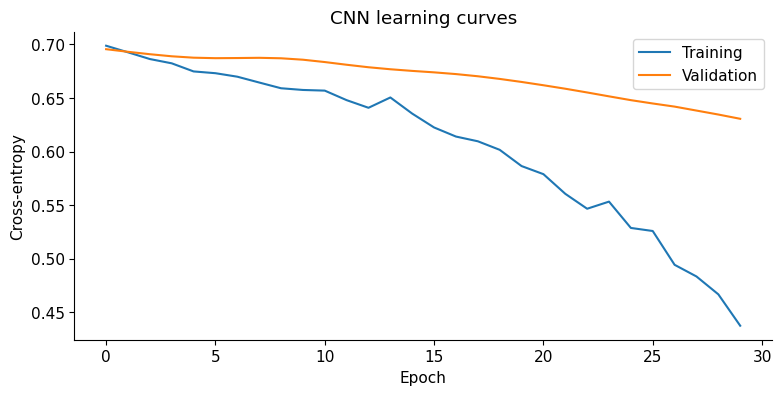

In [7]:
import copy
net=nn.Sequential(nn.Conv1d(X.shape[1],16,15,padding=7),nn.ELU(),
                  nn.AvgPool1d(4),nn.Dropout(.25),nn.Conv1d(16,16,9,padding=4),
                  nn.ELU(),nn.AdaptiveAvgPool1d(1),nn.Flatten(),nn.Linear(16,2))
opt=torch.optim.Adam(net.parameters(),lr=.001,weight_decay=.01)
loss_fn=nn.CrossEntropyLoss()
history=[]; best_loss=float('inf'); best=None
for epoch in range(30):
    net.train(); opt.zero_grad()
    loss=loss_fn(net(Z[tr_t]),Y[tr_t]); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad(): val=loss_fn(net(Z[va_t]),Y[va_t]).item()
    history.append((loss.item(),val))
    if val<best_loss: best_loss=val; best=copy.deepcopy(net.state_dict())
net.load_state_dict(best); net.eval()
with torch.no_grad(): pred=net(Z[te_t]).argmax(1).numpy()
print('Test-run balanced accuracy:',balanced_accuracy_score(y[te],pred))
fig,ax=plt.subplots(); ax.plot(history)
ax.set(xlabel='Epoch',ylabel='Cross-entropy',title='CNN learning curves')
ax.legend(['Training','Validation']); plt.show()

### Inspect and interpret

Read learning curves before the final metric. If training improves while validation worsens, explain why the last epoch is not automatically the best model.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Train a denoising autoencoder
Only training epochs are used. The target is recorded EEG, not verified clean EEG. Evaluate added-noise reconstruction on the validation set, leaving the test set for the classifier result above.

The autoencoder is trained against recorded EEG after adding controlled noise. Its reconstruction objective differs from the classifier’s label objective. Validation compares the reconstructed signal to the recorded target under the stated corruption.

In [8]:
ae=nn.Sequential(nn.Conv1d(X.shape[1],8,9,padding=4),nn.ELU(),
                 nn.Conv1d(8,X.shape[1],9,padding=4))
optimizer=torch.optim.Adam(ae.parameters(),lr=.003)
for _ in range(20):
    corrupted=Z[tr_t]+.2*torch.randn_like(Z[tr_t])
    optimizer.zero_grad(); loss=((ae(corrupted)-Z[tr_t])**2).mean()
    loss.backward(); optimizer.step()
ae.eval()
with torch.no_grad():
    noisy=Z[va_t]+.2*torch.randn_like(Z[va_t])
    reconstructed=ae(noisy)
    print('Validation MSE: noisy input',((noisy-Z[va_t])**2).mean().item(),
          'autoencoder',((reconstructed-Z[va_t])**2).mean().item())
print('A worse reconstruction score is a valid outcome; do not claim denoising succeeded automatically.')

Validation MSE: noisy input 0.039917685091495514 autoencoder 0.3346235454082489
A worse reconstruction score is a valid outcome; do not claim denoising succeeded automatically.


### Inspect and interpret

Report the unchanged noisy-input baseline as well as reconstructed MSE in the exercise. A low error against recorded EEG does not certify removal of real ocular or muscle artifacts.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Independent practice

Work through the tasks in order. Exercise 1 includes a small implementation check; passing it verifies the stated example, not every possible input. For the investigations, save a labeled figure or table and a short explanation. Use copies of data objects when changing preprocessing, and preserve any held-out evaluation partition.

**Submission:** your completed notebook, the requested outputs, and a brief exit-ticket response. The notebook runs before exercises are completed; “pending” means your work is still required.

### Exercise 1 · Cross-entropy function

Implement mean_nll for a vector of probabilities assigned to the correct class. Use values strictly between zero and one.

In [9]:
def mean_nll(correct_class_probabilities):
    # TODO: average negative natural-log probability.
    return None

In [10]:
answer=mean_nll(np.array([.5,.5]))
if answer is not None:
    assert np.isclose(answer,np.log(2)); print('Loss check passed.')
else: print('Exercise pending: implement mean_nll.')

Exercise pending: implement mean_nll.


**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 2 · Shape audit

Annotate the real network with input/output dimensions at each layer and verify them with a dummy batch.

In [11]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 3 · Learning curves

Plot training and validation loss together. Identify a checkpoint choice and distinguish underfitting from overfitting using evidence.

In [12]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 4 · Baseline comparison

Compare the CNN with a fixed band-power model using the same train/validation/test runs. Do not claim superiority from a single favorable seed.

In [13]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 5 · Autoencoder stress test

Vary synthetic corruption amplitude and compare reconstruction MSE with an unchanged-input baseline. State what the clean target actually represents.

In [14]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 6 · Exit ticket

Explain why neither low reconstruction loss nor high training accuracy establishes a useful neural interface.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

## Next steps and sources
[PyTorch training basics](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html) · [MNE EEGBCI](https://mne.tools/stable/generated/mne.datasets.eegbci.load_data.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.